In [1]:
import numpy as np
from PIL import Image
import cv2 as cv
from IPython.display import display
import importlib
import numpy as np

In [2]:
def display_img(image, width=300):
    low, high = np.percentile(image, (1, 99))  
    img_clip = np.clip(image, low, high)
    img_clip = 255 * (img_clip - low) / (high - low)
    img_clip = img_clip.astype(np.uint8)

    pil_img = Image.fromarray(img_clip)
    display(pil_img.resize(
        (width, int(pil_img.height * width / pil_img.width))
    ))

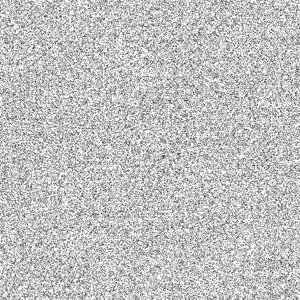

In [3]:
from ghostseal_generator import gen_random_binary_texture
shape = 2000
dilation_size_i = 1
density = 0.01
angle_shift = 90
norm_shift = 100

binary_dots_texture = gen_random_binary_texture(shape,shape, dilation_size_i,density, angle_shift, norm_shift)
display_img(binary_dots_texture)



# Affinity_projection

Image sauvegardée : result_affinity.png


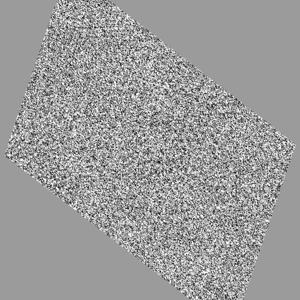

In [4]:
import affinity_projection as aff
importlib.reload(aff)

output_path = "result_affinity.png"

input_image = binary_dots_texture

result = aff.deform_image_affinity(
    input_image=input_image,
    lambdaa=1,
    theta=40,
    tilt=0.6,
    phi=30,
    translation=(0, 0),
    apply_blur=True,
    blur_ksize=(11, 11),
    blur_sigma=0
)

Image.fromarray(result).save(output_path)
print("Image sauvegardée :", output_path)
display_img(result)

In [5]:
point_xy = (1000, 1000)

diff_info = aff.differential_at_image_point(
    point_xy=point_xy,
    lambdaa=1,
    theta=40,
    tilt=0.6,
    phi=30,
    translation=(0, 0),
    source_shape=input_image.shape
)

print("Point image :", diff_info["point_image"])
print("Point source :", diff_info["point_label"])
print("Jacobienne J =")
print(diff_info["J"])

Point image : [1000. 1000.]
Point source : [1019.90354566  964.08489048]
Jacobienne J =
[[ 0.76122435 -0.21206148]
 [ 0.58793852  0.62441629]]


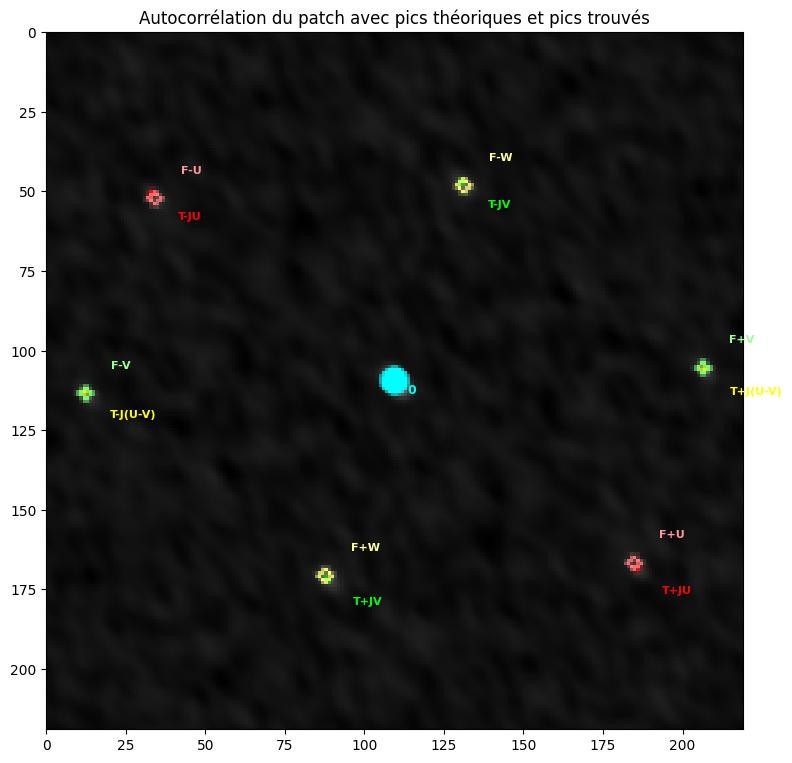

Point source : [1125.93428358 1344.69706633]
J =
 [[ 0.76122435 -0.21206148]
 [ 0.58793852  0.62441629]]
Pics théoriques :
+JU [185.62243517 168.29385242]
-JU [33.37756483 50.70614758]
+JV [ 88.29385242 171.94162944]
-JV [130.70614758  47.05837056]
+J(U-V) [206.82858275 105.85222298]
-J(U-V) [ 12.17141725 113.14777702]


In [6]:
integrated = True
d = 2
R_int = 3
lam = 1.0
search_kwargs = dict(
    k=40,
    nms_size=40,
    exclude_center_radius=30.0,
    min_separation=10.0,
    refine_model='tps',
    refine_halfwin=3,
    tps_coarse_step=0.1,
    energy_halfwin=1.5,
    min_dist=20.0,
    antipodal_tol=10.0,
    angle_min_deg=20.0,
    w_exclude_center_radius=30.0,
    integrated=integrated, d=d, R_int=R_int, lam=lam
)
res_ac = aff.autocorr_with_theoretical_peaks(
    deformed_image=result,
    point_xy=(1000, 1300),
    patch_size=220,
    U_init=np.array([100, 0.0]),
    V_init=np.array([0.0, 100]),
    lambdaa=1,
    theta=40,
    tilt=0.6,
    phi=30,
    translation=(0, 0),
    source_image_shape=np.asarray(input_image).shape,
    shift_units="source_px",
    show=True,
    stable_kwargs=dict(
        min_ps=40,
        max_ps=300,
        step=2,
        stable_seq_len=10,
        stable_tol=1,
        integrated=True,
        d=2,
        R_int=3,
        lam=1.0,
        show_tracks=False
    )
)

print("Point source :", res_ac["point_label"])
print("J =\n", res_ac["J"])
print("Pics théoriques :")
for k, v in res_ac["peak_pixels"].items():
    print(k, v)



# Homography_projection

Image sauvegardée : result_homography.png


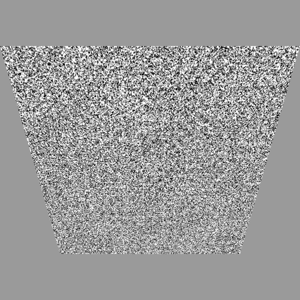

In [7]:
import homography_projection as hom
importlib.reload(hom)

output_path = "result_homography.png"

input_image = binary_dots_texture

angle_vue_x = 30
angle_vue_y = 0
focal = 2000

deformed_img = hom.deform_image_homography(
    input_image=input_image,
    angle_vue_x=angle_vue_x,
    angle_vue_y=angle_vue_y,
    focal=focal,
    apply_blur=True,
    blur_ksize=(11, 11),
    blur_sigma=0
)

Image.fromarray(deformed_img).save(output_path)
print("Image sauvegardée :", output_path)
display_img(deformed_img)

In [8]:
point_xy = (1000, 1000)

diff_info = hom.differential_at_image_point(
    point_xy=point_xy,
    angle_vue_x=angle_vue_x,
    angle_vue_y=angle_vue_y,
    focal=focal,
    source_shape=np.asarray(input_image).shape
)

print("Point image :", diff_info["point_image"])
print("Point sur l'image source :", diff_info["point_label"])
print("Jacobienne J =")
print(diff_info["J"])

Point image : [1000. 1000.]
Point sur l'image source : [1013.70996585  781.46805344]
Jacobienne J =
[[ 0.78480657 -0.01376854]
 [ 0.          0.71120474]]


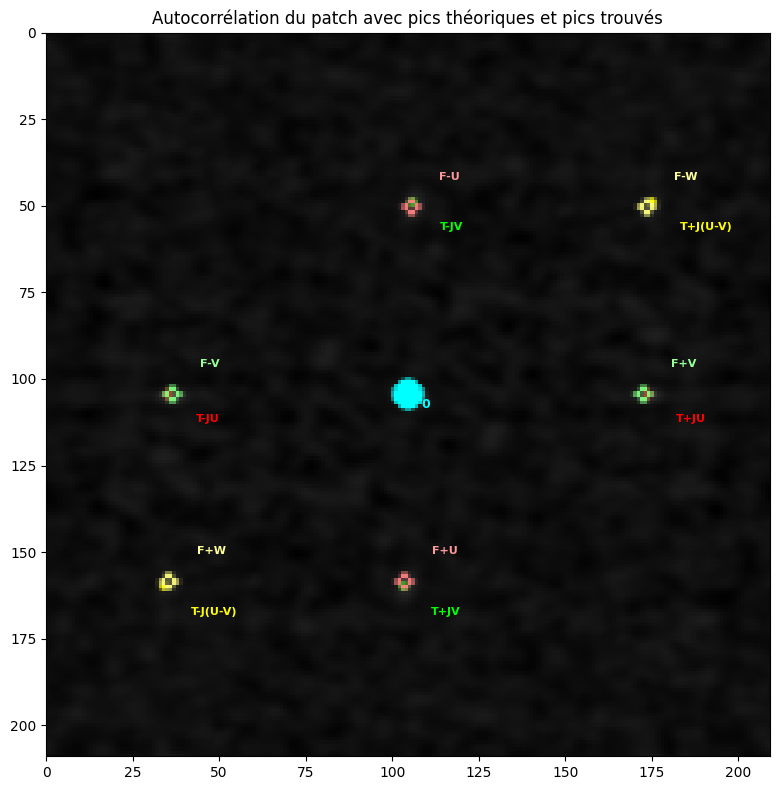

Point source : [1022.08287725 1258.72400326]
J =
 [[ 0.69364601 -0.01216923]
 [ 0.          0.55557816]]
Pics théoriques :
+JU [173.86460073 104.5       ]
-JU [ 35.13539927 104.5       ]
+JV [103.28307718 160.05781562]
-JV [105.71692282  48.94218438]
+J(U-V) [175.08152355  48.94218438]
-J(U-V) [ 33.91847645 160.05781562]


In [9]:
res_ac = hom.autocorr_with_theoretical_peaks(
    deformed_image=deformed_img,
    point_xy=(1000, 1300),
    patch_size=210,
    U_init=np.array([100, 0.0]),
    V_init=np.array([0.0, 100]),
    angle_vue_x=angle_vue_x,
    angle_vue_y=angle_vue_y,
    focal=focal,
    source_image_shape=np.asarray(input_image).shape,
    shift_units="source_px",
    show=True,
    stable_kwargs=dict(
        min_ps=40,
        max_ps=300,
        step=2,
        stable_seq_len=10,
        stable_tol=1,
        integrated=True,
        d=2,
        R_int=3,
        lam=1.0,
        show_tracks=False
    )
)

print("Point source :", res_ac["point_label"])
print("J =\n", res_ac["J"])
print("Pics théoriques :")
for k, v in res_ac["peak_pixels"].items():
    print(k, v)


# Cylindre_projection

Image sauvegardée : result_cylindre.png


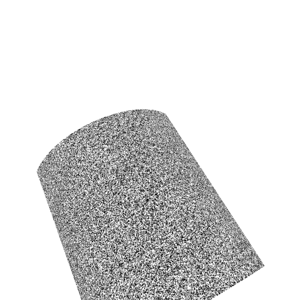

In [10]:
import cylindre_projection as cyl
importlib.reload(cyl)

output_path = "result_cylindre.png"

input_image = binary_dots_texture

radius_cm = 1.1
label_size_factor = 2.0
focal_px = 2000.0
output_size_px = 2000

camera_pos = np.array([4.0, -0.2, -1], dtype=float)
view_dir   = cyl.normalize(np.array([-1.0, 0.2, 0.5], dtype=float))
roll = np.deg2rad(-30.0)

# camera_pos = np.array([4.0, 0.0, 0], dtype=float)

# view_dir = cyl.normalize(np.array([-1.0, 0.0, 0], dtype=float))

# roll = 0.0

deformed_img = cyl.deform_image_cylindrical(
    input_image=input_image,
    radius_cm=radius_cm,
    label_size_factor=label_size_factor,
    camera_pos=camera_pos,
    view_dir=view_dir,
    focal_px=focal_px,
    output_size_px=output_size_px,
    roll=roll,
    apply_blur=True,
    blur_ksize=(11, 11),
    blur_sigma=0
)

Image.fromarray(deformed_img).save(output_path)
print("Image sauvegardée :", output_path)
display_img(deformed_img)


In [11]:
point_xy = (1000, 1000)

diff_info = cyl.differential_at_image_point(
    point_xy=point_xy,
    radius_cm=radius_cm,
    label_size_factor=label_size_factor,
    camera_pos=camera_pos,
    view_dir=view_dir,
    focal_px=focal_px,
    output_size_px=output_size_px,
    roll=roll
)

print("Point image :", diff_info["point_image"])
print("Point sur l'étiquette (u,v) en cm :", diff_info["point_label"])
print("Jacobienne J =")
print(diff_info["J"])


Point image : [1000. 1000.]
Point sur l'étiquette (u,v) en cm : [0.4040097  0.48542722]
Jacobienne J =
[[ 503.02556883 -265.98027489]
 [-129.40819175 -460.64362908]]


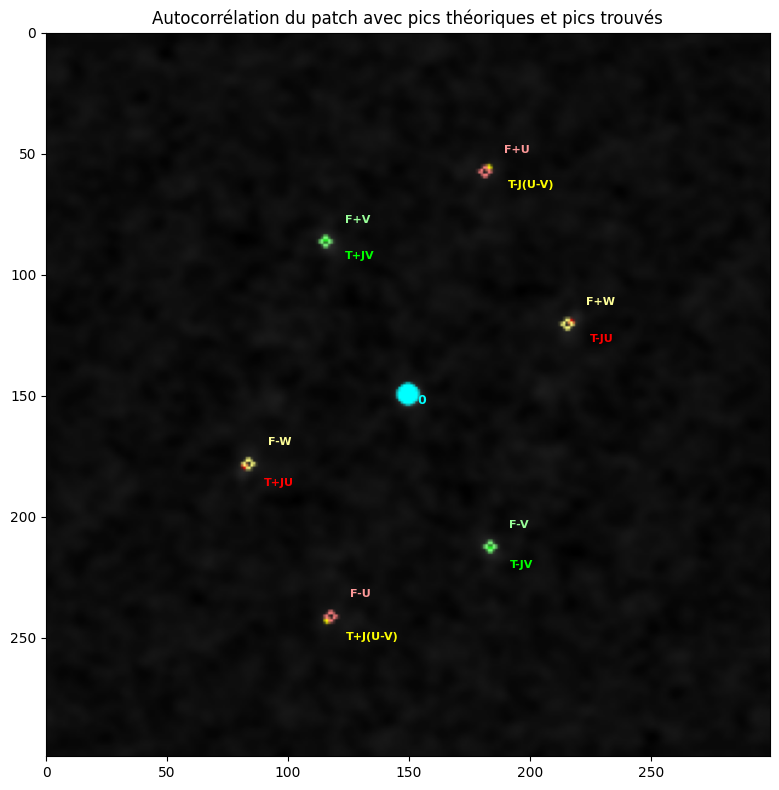

Point étiquette : [ 0.1487943  -0.01114777]
J =
 [[ 582.15638757 -293.61314512]
 [-256.40234935 -551.67632877]]
Pics théoriques (en pixels dans l'autocorrélation) :
+JU [ 82.09241828 179.18869308]
-JU [216.90758172 119.81130692]
+JV [115.50268846  85.62168825]
-JV [183.49731154 213.37831175]
+J(U-V) [116.08972982 243.06700483]
-J(U-V) [182.91027018  55.93299517]


In [12]:
res_ac = cyl.autocorr_with_theoretical_peaks(
    deformed_image=deformed_img,
    point_xy=(1000, 1300),
    patch_size=300,
    U_init=np.array([-100, 0.0]),
    V_init=np.array([0.0, 100]),
    radius_cm=radius_cm,
    label_size_factor=label_size_factor,
    camera_pos=camera_pos,
    view_dir=view_dir,
    focal_px=focal_px,
    output_size_px=output_size_px,
    roll=roll,
    shift_units="source_px",
    source_image_shape=np.asarray(input_image).shape,
    show=True,
    stable_kwargs=dict(
        min_ps=40,
        max_ps=300,
        step=2,
        stable_seq_len=10,
        stable_tol=4,
        integrated=True,
        d=2,
        R_int=3,
        lam=1.0,
        show_tracks=False
    )
)
print("Point étiquette :", res_ac["point_label"])
print("J =\n", res_ac["J"])
print("Pics théoriques (en pixels dans l'autocorrélation) :")
for k, v in res_ac["peak_pixels"].items():
    print(k, v)
    


# Saddle_projection

Image sauvegardée : result_saddle.png


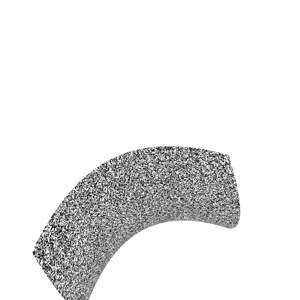

In [13]:
import saddle_projection as sad
importlib.reload(sad)


output_path = "result_saddle.png"

input_image = binary_dots_texture

radius_cm = 1.1
label_size_factor = 2.0
focal_px = 2000.0
output_size_px = 2000

camera_pos = np.array([4.0, -0.2, -1], dtype=float)
view_dir   = sad.normalize(np.array([-1.0, 0.2, 0.5], dtype=float))
roll = np.deg2rad(-30.0)

deformed_img = sad.deform_image_saddle(
    input_image=input_image,
    radius_cm=radius_cm,
    label_size_factor=label_size_factor,
    camera_pos=camera_pos,
    view_dir=view_dir,
    focal_px=focal_px,
    output_size_px=output_size_px,
    roll=roll,
    apply_blur=True,
    blur_ksize=(11, 11),
    blur_sigma=0
)

Image.fromarray(deformed_img).save(output_path)
print("Image sauvegardée :", output_path)
display_img(deformed_img)


In [14]:
point_xy = (1000, 1000)

diff_info = sad.differential_at_image_point(
    point_xy=point_xy,
    radius_cm=radius_cm,
    label_size_factor=label_size_factor,
    camera_pos=camera_pos,
    view_dir=view_dir,
    focal_px=focal_px,
    output_size_px=output_size_px,
    roll=roll
)

print("Point image :", diff_info["point_image"])
print("Point sur l'étiquette (u,v) en cm :", diff_info["point_label"])
print("Jacobienne J =")
print(diff_info["J"])

Point image : [1000. 1000.]
Point sur l'étiquette (u,v) en cm : [1.07723905 0.38486193]
Jacobienne J =
[[-292.56977552  632.36074942]
 [-743.14168614  -86.44871303]]


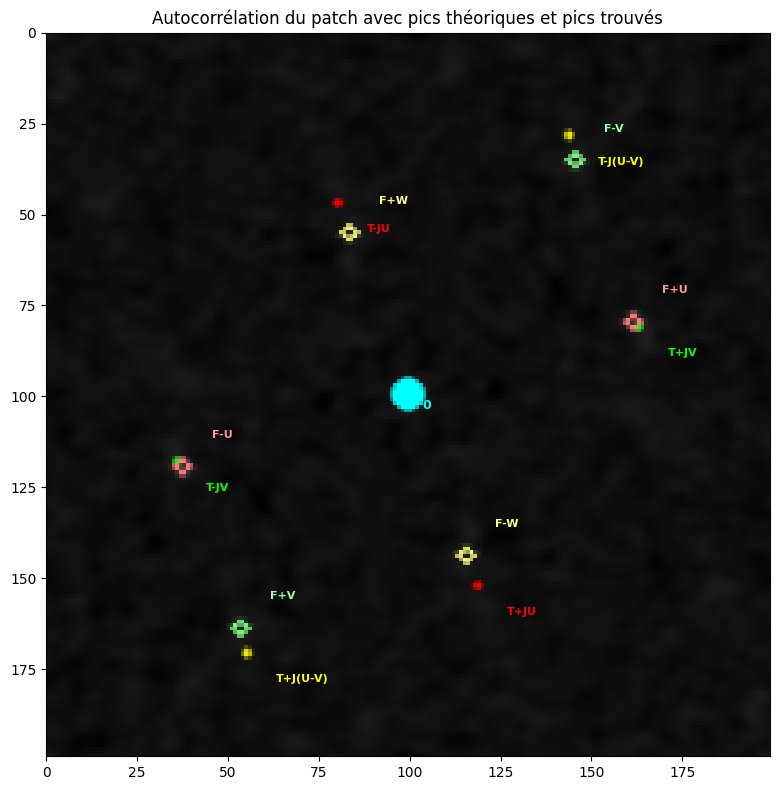

Point étiquette : [0.61224102 0.20552428]
J =
 [[-166.0864001   548.30001437]
 [-454.49901495 -159.69658193]]
Pics théoriques :
+JU [118.73105685 152.12620173]
-JU [80.26894315 46.87379827]
+JV [162.98737009  81.00881683]
-JV [ 36.01262991 117.99118317]
+J(U-V) [ 55.24368677 170.6173849 ]
-J(U-V) [143.75631323  28.3826151 ]


In [16]:
res_ac = sad.autocorr_with_theoretical_peaks(
    deformed_image=deformed_img,
    point_xy=(1000, 1300),
    patch_size=200,
    U_init=np.array([-100, 0.0]),
    V_init=np.array([0.0, 100]),
    radius_cm=radius_cm,
    label_size_factor=label_size_factor,
    camera_pos=camera_pos,
    view_dir=view_dir,
    focal_px=focal_px,
    output_size_px=output_size_px,
    roll=roll,
    shift_units="source_px",
    source_image_shape=np.asarray(input_image).shape,
    show=True,
    stable_kwargs=dict(
        min_ps=40,
        max_ps=200,
        step=2,
        stable_seq_len=10,
        stable_tol=4,
        integrated=True,
        d=2,
        R_int=3,
        lam=1.0,
        show_tracks=False
    )
)

print("Point étiquette :", res_ac["point_label"])
print("J =\n", res_ac["J"])
print("Pics théoriques :")
for k, v in res_ac["peak_pixels"].items():
    print(k, v)

